# Machine Learning - Lab 2 Bonus
## Machine Learning with Scikit-Learn Basics

#Part 1: Setting Up Your Environment

In [ ]:
import sklearn
print(f"scikit-learn version: {sklearn.__version__}")
import numpy as np
import matplotlib.pyplot as plt
print("All libraries loaded successfully!")

scikit-learn version: 1.6.1
All libraries loaded successfully!


#Part 2: Loading and Exploring Data

In [ ]:
# Upload dataset manually
from google.colab import files

uploaded = files.upload()

Saving RAMEDIS.jsonl to RAMEDIS.jsonl


In [ ]:
df = pd.read_json("RAMEDIS.jsonl", lines=True)

# Explore data
# Features (X) and Labels (y)
X = df["Phenotype"]
y = df["RareDisease"]

# Let's see what we have
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nFirst 5 rows:")
print(df.head())

print("\nExample Phenotype:")
print(X.iloc[0])

print("\nExample RareDisease:")
print(y.iloc[0])

Shape: (624, 3)

Columns:
Index(['Phenotype', 'RareDisease', 'Department'], dtype='object')

First 5 rows:
                                           Phenotype  \
0   [HP:0001522, HP:0001942, HP:0003210, HP:0003819]   
1  [HP:0001270, HP:0001290, HP:0001522, HP:000209...   
2  [HP:0001197, HP:0001522, HP:0003231, HP:000381...   
3  [HP:0000776, HP:0001270, HP:0001272, HP:000150...   
4  [HP:0000126, HP:0000750, HP:0001197, HP:000124...   

                         RareDisease  Department  
0   [OMIM:251000, ORPHA:27, CCRD:71]         NaN  
1            [OMIM:271980, ORPHA:22]         NaN  
2  [OMIM:261600, ORPHA:716, CCRD:90]         NaN  
3         [OMIM:212065, ORPHA:79318]         NaN  
4  [OMIM:248600, ORPHA:511, CCRD:67]         NaN  

Example Phenotype:
['HP:0001522', 'HP:0001942', 'HP:0003210', 'HP:0003819']

Example RareDisease:
['OMIM:251000', 'ORPHA:27', 'CCRD:71']


In [ ]:
# Check missing values
print("Missing values:")
print(df.isna().sum())

Missing values:
Phenotype        0
RareDisease      0
Department     624
dtype: int64


In [ ]:
df = df.drop(columns=["Department"])

print("\nMissing values after dropping Department:")
print(df.isna().sum())


Missing values after dropping Department:
Phenotype      0
RareDisease    0
dtype: int64


Quick *Visualization*

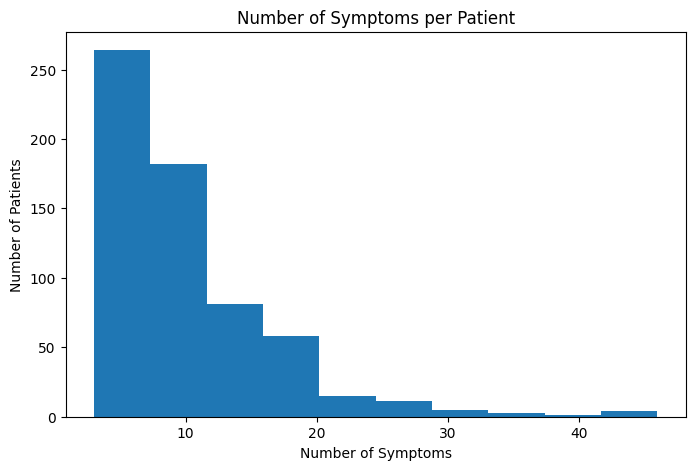

In [ ]:
# Count symptoms per patient
symptom_counts = X.apply(len)

plt.figure(figsize=(8,5))
plt.hist(symptom_counts)
plt.title("Number of Symptoms per Patient")
plt.xlabel("Number of Symptoms")
plt.ylabel("Number of Patients")
plt.show()

#Part 3: Splitting Data (Train/Test)

In [ ]:
from sklearn.model_selection import train_test_split

# Features (X) and Labels (y)
X = df["Phenotype"].apply(lambda x: " ".join(x))
y = df["RareDisease"].apply(lambda x: x[0])  # take first disease

# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 20% testing
    random_state=42,    # reproducibility

)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

Training set: 499 samples
Testing set: 125 samples


#Part 4: Training Your Model

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert phenotype list -> text
X_train_text = X_train.apply(lambda x: " ".join(x) if isinstance(x, list) else x)
X_test_text  = X_test.apply(lambda x: " ".join(x) if isinstance(x, list) else x)

# Vectorize text into numeric features
vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train_text)
X_test_vec  = vectorizer.transform(X_test_text)

print("Vectorized training shape:", X_train_vec.shape)
print("Vectorized testing shape:", X_test_vec.shape)

Vectorized training shape: (499, 459)
Vectorized testing shape: (125, 459)


Model A: Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Step 1: Create
dt_model = DecisionTreeClassifier(random_state=42)

# Step 2: Train
dt_model.fit(X_train_vec, y_train)

# Step 3: Predict
dt_predictions = dt_model.predict(X_test_vec)

print("Decision Tree predictions (first 10):")
print(dt_predictions[:10])

print("\nActual labels (first 10):")
print(list(y_test[:10]))

Decision Tree predictions (first 10):
['OMIM:210200' 'OMIM:231670' 'OMIM:212065' 'OMIM:231670' 'OMIM:605814'
 'OMIM:231670' 'OMIM:215700' 'OMIM:261600' 'OMIM:212065' 'OMIM:311250']

Actual labels (first 10):
['OMIM:210200', 'OMIM:231670', 'OMIM:212065', 'OMIM:231670', 'OMIM:215700', 'OMIM:246450', 'OMIM:271900', 'OMIM:261600', 'OMIM:212065', 'OMIM:311250']


Model B: K-Nearest Neighbors (KNN)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Step 1: Create
knn_model = KNeighborsClassifier(n_neighbors=5)

# Step 2: Train
knn_model.fit(X_train_vec, y_train)

# Step 3: Predict
knn_predictions = knn_model.predict(X_test_vec)

print("KNN predictions (first 10):")
print(knn_predictions[:10])

print("\nActual labels (first 10):")
print(list(y_test[:10]))

KNN predictions (first 10):
['OMIM:210200' 'OMIM:231670' 'OMIM:212065' 'OMIM:251000' 'OMIM:215700'
 'OMIM:251000' 'OMIM:201470' 'OMIM:261600' 'OMIM:212065' 'OMIM:311250']

Actual labels (first 10):
['OMIM:210200', 'OMIM:231670', 'OMIM:212065', 'OMIM:231670', 'OMIM:215700', 'OMIM:246450', 'OMIM:271900', 'OMIM:261600', 'OMIM:212065', 'OMIM:311250']


#Part 5: Evaluate Model

Accuracy Score

In [ ]:
from sklearn.metrics import accuracy_score

# Accuracy for Decision Tree
dt_accuracy = accuracy_score(y_test, dt_predictions)

# Accuracy for KNN
knn_accuracy = accuracy_score(y_test, knn_predictions)

print(f"Decision Tree Accuracy: {dt_accuracy:.2f}")
print(f"KNN Accuracy:          {knn_accuracy:.2f}")

Decision Tree Accuracy: 0.70
KNN Accuracy:          0.72


Classification Report

In [ ]:
from sklearn.metrics import classification_report

print("=== Decision Tree Report ===")
print(classification_report(y_test, dt_predictions))

print("\n=== KNN Report ===")
print(classification_report(y_test, knn_predictions))

=== Decision Tree Report ===
              precision    recall  f1-score   support

 OMIM:125850       1.00      1.00      1.00         1
 OMIM:201450       0.44      0.67      0.53         6
 OMIM:201475       0.00      0.00      0.00         2
 OMIM:203500       1.00      1.00      1.00         1
 OMIM:210200       1.00      0.67      0.80         3
 OMIM:212065       0.86      1.00      0.92         6
 OMIM:212140       0.00      0.00      0.00         1
 OMIM:215700       0.00      0.00      0.00         2
 OMIM:220110       0.00      0.00      0.00         2
 OMIM:230400       1.00      1.00      1.00         2
 OMIM:231670       0.79      1.00      0.88        11
 OMIM:232200       0.00      0.00      0.00         1
 OMIM:236200       0.50      0.50      0.50         2
 OMIM:236250       0.00      0.00      0.00         1
 OMIM:236792       1.00      0.50      0.67         4
 OMIM:237300       0.00      0.00      0.00         4
 OMIM:243500       0.00      0.00      0.00         

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

Confusion Matrix (Visual)

<Figure size 1000x700 with 0 Axes>

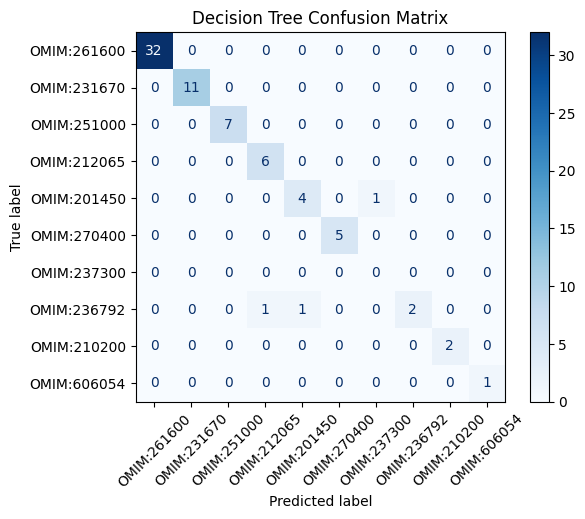

<Figure size 1000x700 with 0 Axes>

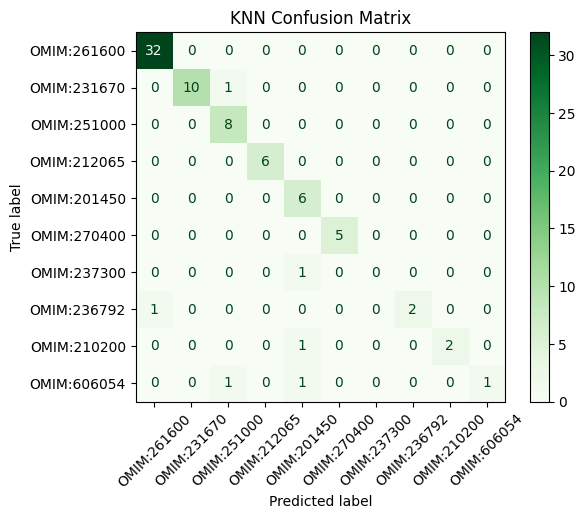

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Choose top N diseases in the test set
top_n = 10
top_classes = y_test.value_counts().head(top_n).index

# Filter test and predictions to only those classes
mask = y_test.isin(top_classes)

y_test_top = y_test[mask]
dt_pred_top = dt_predictions[mask]
knn_pred_top = knn_predictions[mask]

# Decision Tree confusion matrix
cm_dt = confusion_matrix(y_test_top, dt_pred_top, labels=top_classes)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=top_classes)

plt.figure(figsize=(10,7))
disp_dt.plot(cmap="Blues", xticks_rotation=45)
plt.title("Decision Tree Confusion Matrix")
plt.show()


# KNN confusion matrix
cm_knn = confusion_matrix(y_test_top, knn_pred_top, labels=top_classes)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=top_classes)

plt.figure(figsize=(10,7))
disp_knn.plot(cmap="Greens", xticks_rotation=45)
plt.title("KNN Confusion Matrix")
plt.show()

The confusion matrices show that both Decision Tree and KNN models correctly classified most disease cases, as indicated by the high values along the diagonal. Only a small number of misclassifications occurred, which is expected due to similarities between some diseases and the limited dataset size. Overall, the Decision Tree model performed slightly better, with fewer classification errors compared to KNN.